# Workstream A — Panier FX
## Estimation des poids EUR/USD, GBP/USD, USD/JPY → USD/TND




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

FILE = r"C:\Users\eyasf\OneDrive\Desktop\TSA_project\Data\FX Data.xlsx"
xls = pd.ExcelFile(FILE)


Bct_fixing_USD = pd.read_excel(xls, "BCT Fixing USD")
FX_data        = pd.read_excel(xls, "EUR-GBP-JPY vs USD")

Fix = Bct_fixing_USD[['Exchange Date','Mid Price']].copy()
Fix.columns = ['Date','Fixing_USD']
Fix['Date'] = pd.to_datetime(Fix['Date'])
Fix = Fix.dropna().sort_values('Date').reset_index(drop=True)

FX = FX_data.iloc[1:].copy()
FX.columns = ['Date','EURUSD','GBPUSD','USDJPY']
FX['Date'] = pd.to_datetime(FX['Date'])
for c in ['EURUSD','GBPUSD','USDJPY']:
    FX[c] = pd.to_numeric(FX[c], errors='coerce')
FX = FX.dropna().sort_values('Date').reset_index(drop=True)

# ── Merge et log-returns  ──────────────────
data_A = pd.merge(Fix, FX, on='Date', how='inner').sort_values('Date').reset_index(drop=True)
for col in ['Fixing_USD','EURUSD','GBPUSD','USDJPY']:
    data_A[f'r_{col}'] = np.log(data_A[col]).diff()
data_A = data_A.dropna().reset_index(drop=True)

print(f"Dataset A : {len(data_A)} obs  ({data_A['Date'].min().date()} → {data_A['Date'].max().date()})")
data_A.head()


Dataset A : 1421 obs  (2020-04-13 → 2026-01-27)


,Date,Fixing_USD,EURUSD,GBPUSD,USDJPY,r_Fixing_USD,r_EURUSD,r_GBPUSD,r_USDJPY
0,2020-04-13,2.89680,1.0913,1.2507,107.76,-0.003309,-0.002014,0.004407,-0.006475
1,2020-04-14,2.88910,1.0979,1.2623,107.20,-0.002662,0.006030,0.009232,-0.005210
2,2020-04-15,2.89520,1.0907,1.2514,107.47,0.002109,-0.006580,-0.008673,0.002515
3,2020-04-16,2.90135,1.0835,1.2455,107.94,0.002122,-0.006623,-0.004726,0.004364
4,2020-04-17,2.90870,1.0876,1.2499,107.51,0.002530,0.003777,0.003526,-0.003992


In [2]:
#  OLS Basket  
X = sm.add_constant(data_A[['r_EURUSD','r_GBPUSD','r_USDJPY']])
y = data_A['r_Fixing_USD']
model_OLS = sm.OLS(y, X).fit()
print(model_OLS.summary())

w_EUR = model_OLS.params['r_EURUSD']
w_GBP = model_OLS.params['r_GBPUSD']
w_JPY = model_OLS.params['r_USDJPY']
print(f"\nPoids retenus : w_EUR={w_EUR:.4f}, w_GBP={w_GBP:.4f}, w_JPY={w_JPY:.4f}")
print(f"R² = {model_OLS.rsquared:.4f}")


                            OLS Regression Results                            
Dep. Variable:           r_Fixing_USD   R-squared:                       0.397
Model:                            OLS   Adj. R-squared:                  0.396
Method:                 Least Squares   F-statistic:                     311.6
Date:                Wed, 13 May 2026   Prob (F-statistic):          2.53e-155
Time:                        21:40:05   Log-Likelihood:                 6498.3
No. Observations:                1421   AIC:                        -1.299e+04
Df Residuals:                    1417   BIC:                        -1.297e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       7.536e-06   6.65e-05      0.113      0.9

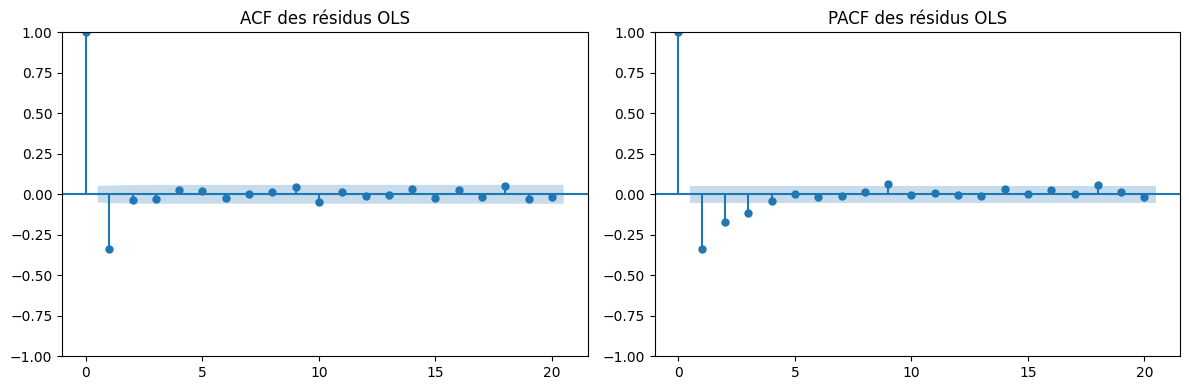

Durbin-Watson : 2.6786


In [3]:
# Résidus OLS  
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.stattools import durbin_watson

residuals_OLS = model_OLS.resid
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(residuals_OLS,  lags=20, ax=axes[0], title="ACF des résidus OLS")
plot_pacf(residuals_OLS, lags=20, ax=axes[1], title="PACF des résidus OLS")
plt.tight_layout()
plt.show()

dw = durbin_watson(residuals_OLS)
print(f"Durbin-Watson : {dw:.4f}")


<Figure size 1200x500 with 0 Axes>

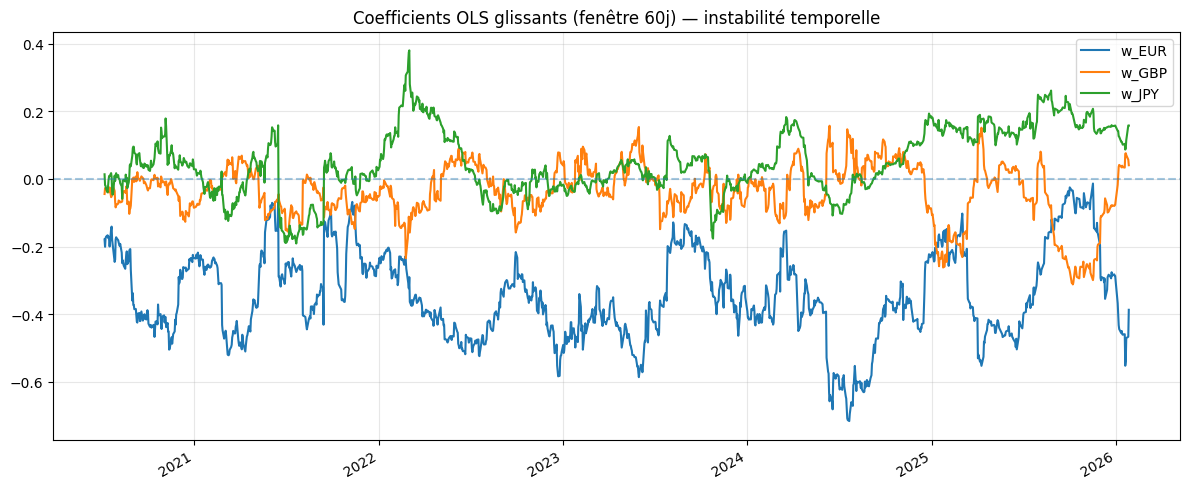

→ Coefficients instables dans le temps


In [4]:

window = 60
betas = []
dates_roll = []
for i in range(window, len(data_A)+1):
    X_w = sm.add_constant(data_A[['r_EURUSD','r_GBPUSD','r_USDJPY']].iloc[i-window:i])
    y_w = data_A['r_Fixing_USD'].iloc[i-window:i]
    m_w = sm.OLS(y_w, X_w).fit()
    betas.append([m_w.params['r_EURUSD'], m_w.params['r_GBPUSD'], m_w.params['r_USDJPY']])
    dates_roll.append(data_A['Date'].iloc[i-1])

betas_df = pd.DataFrame(betas, columns=['w_EUR','w_GBP','w_JPY'], index=dates_roll)

plt.figure(figsize=(12,5))
betas_df.plot(figsize=(12,5))
plt.axhline(0, linestyle='--', alpha=0.4)
plt.title('Coefficients OLS glissants (fenêtre 60j) — instabilité temporelle')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('WS_A_rolling_betas.png', dpi=150, bbox_inches='tight')
plt.show()
print("→ Coefficients instables dans le temps")


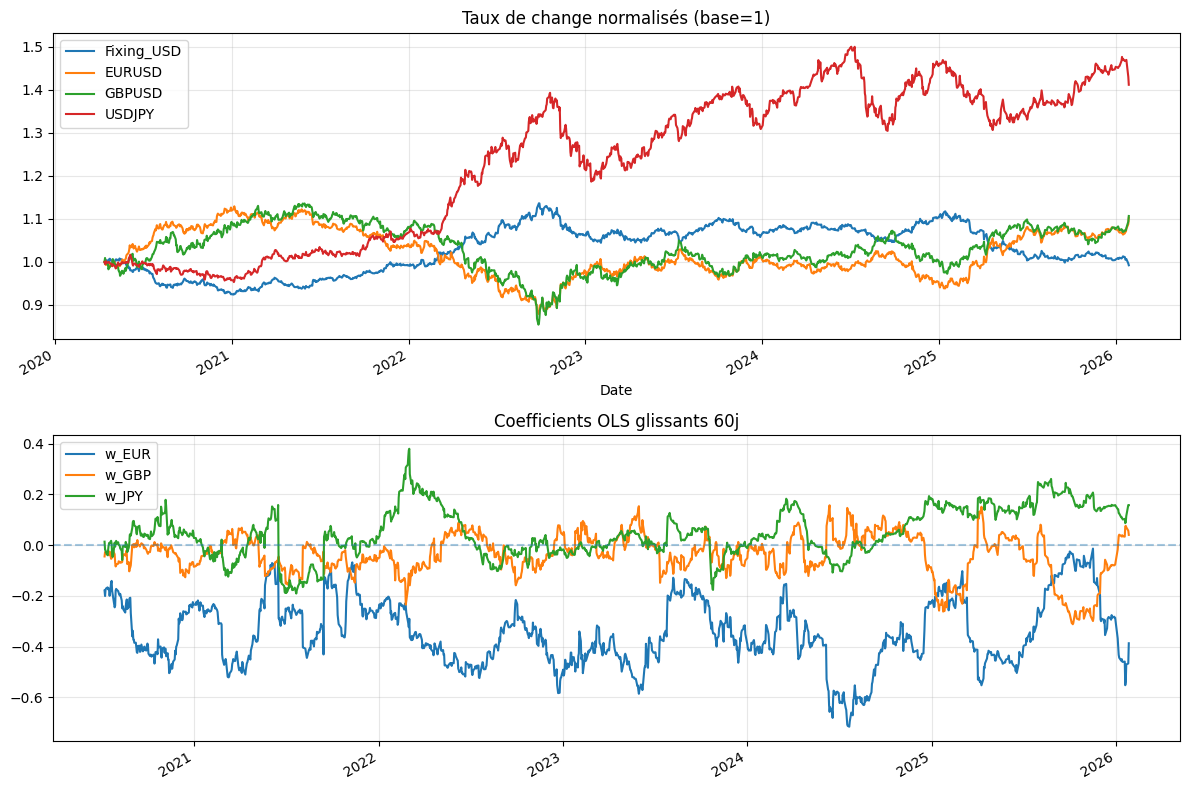


Poids sauvegardés : {'w_EUR': np.float64(-0.3653804212428254), 'w_GBP': np.float64(-0.031768386761918), 'w_JPY': np.float64(0.049631287938964846)}


In [5]:
# Visualisation normalized
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

norm = data_A.set_index('Date')[['Fixing_USD','EURUSD','GBPUSD','USDJPY']]
(norm / norm.iloc[0]).plot(ax=axes[0])
axes[0].set_title('Taux de change normalisés (base=1)')
axes[0].grid(True, alpha=0.3)

betas_df.plot(ax=axes[1])
axes[1].axhline(0, linestyle='--', alpha=0.4)
axes[1].set_title('Coefficients OLS glissants 60j')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('WS_A_overview.png', dpi=150, bbox_inches='tight')
plt.show()

#save the weights
import json
weights = {'w_EUR': w_EUR, 'w_GBP': w_GBP, 'w_JPY': w_JPY}
with open('basket_weights.json', 'w') as f:
    json.dump(weights, f)
print(f"\nPoids sauvegardés : {weights}")
